# **Denoising Autoencoder for Handwritten Digit Reconstruction (MNIST)**

## Import Libraries

In [74]:
# Data Handling & Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Model Building
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import layers, models

# Model Evaluation
from skimage.metrics import structural_similarity as ssim

## Import Data Set

In [60]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [61]:
print('MNIST Dataset Shape:')
print('X_train: ' + str(X_train.shape))
print('Y_train: ' + str(y_train.shape))
print('X_test:  '  + str(X_test.shape))
print('Y_test:  '  + str(y_test.shape))

MNIST Dataset Shape:
X_train: (60000, 28, 28)
Y_train: (60000,)
X_test:  (10000, 28, 28)
Y_test:  (10000,)


## Preprocessing the Data

In [62]:
# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [63]:
# Flatten to 1D vectors
x_train_flat = X_train.reshape(-1, 784)
x_test_flat  = X_test.reshape(-1, 784)

In [64]:
# Add Guassian Noise
noise_factor = 0.2

x_train_noisy = x_train_flat + noise_factor * np.random.normal(size=x_train_flat.shape)
x_test_noisy  = x_test_flat  + noise_factor * np.random.normal(size=x_test_flat.shape)

# Clip values to keep them in valid range [0,1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

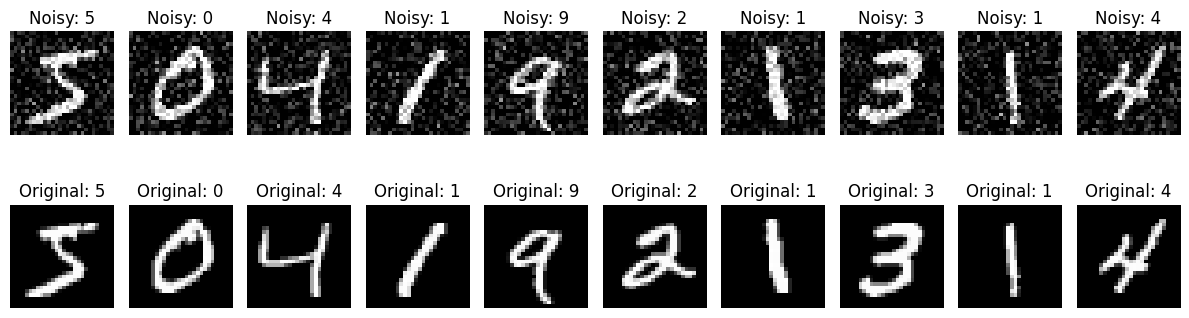

In [65]:
# Show first 10 images
plt.figure(figsize=(12, 4))

for i in range(10):
    # Noisy image
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap="gray")
    plt.title(f"Noisy: {y_train[i]}")
    plt.axis("off")

    # Original image
    plt.subplot(2, 10, i + 11)
    plt.imshow(x_train_flat[i].reshape(28, 28), cmap="gray")
    plt.title(f"Original: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 1. Model Design

In [66]:
input_img = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)

# Decoder
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

# Autoencoder
autoencoder = Model(input, x)
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 14, 14, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

# 2. Model Training

In [67]:
x_train_noisy_reshaped = x_train_noisy.reshape(-1, 28, 28, 1)
x_test_noisy_reshaped = x_test_noisy.reshape(-1, 28, 28, 1)

x_train_flat_reshaped = x_train_flat.reshape(-1, 28, 28, 1)
x_test_flat_reshaped = x_test_flat.reshape(-1, 28, 28, 1)

history = autoencoder.fit(
    x_train_noisy_reshaped, x_train_flat_reshaped,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy_reshaped, x_test_flat_reshaped)
)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 133s 556ms/step - loss: 0.2181 - val_loss: 0.0945
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 128s 547ms/step - loss: 0.0887 - val_loss: 0.0834
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 133s 568ms/step - loss: 0.0825 - val_loss: 0.0801
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 128s 546ms/step - loss: 0.0798 - val_loss: 0.0782
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 144s 555ms/step - loss: 0.0783 - val_loss: 0.0770
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 148s 581ms/step - loss: 0.0772 - val_loss: 0.0761
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 136s 577ms/step - loss: 0.0764 - val_loss: 0.0754
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 140s 567ms/step - loss: 0.0758 - val_loss: 0.0750
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 141s 563ms/step - loss: 0.0753 - val_loss: 0.0756
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 146s 580ms/step - loss: 0.0749 - val_loss: 0.0742
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 137s 585ms/step - loss: 0.0745 - val_loss: 0.0738
Epoch 12

# 3. Model Evaluation and Visualization

## - Plot the Training vs Validation Loss

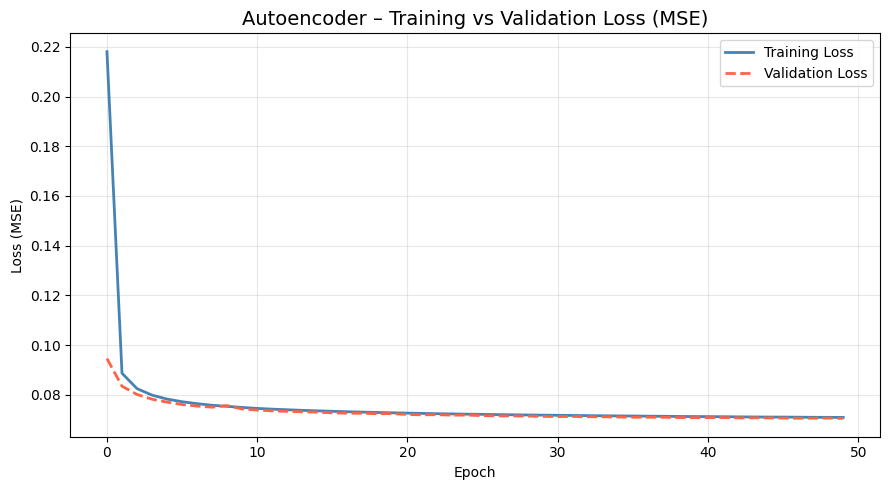

In [80]:
# Training vs Validation Loss
plt.figure(figsize=(9, 5))
plt.plot(history.history["loss"],     label="Training Loss",   linewidth=2, color="steelblue")
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2, color="tomato", linestyle="--")
plt.title("Autoencoder – Training vs Validation Loss (MSE)", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()

In [69]:
# Get reconstructions for the first 10 test images
reconstructed_imgs = autoencoder.predict(x_test_flat_reshaped[:10])

# Reshape from 784 back to 28×28 for display
original_imgs      = x_test_flat[:10].reshape(-1, 28, 28)
reconstructed_imgs = reconstructed_imgs.reshape(-1, 28, 28)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


## - Side-by-Side Comparison of Original vs Reconstructed

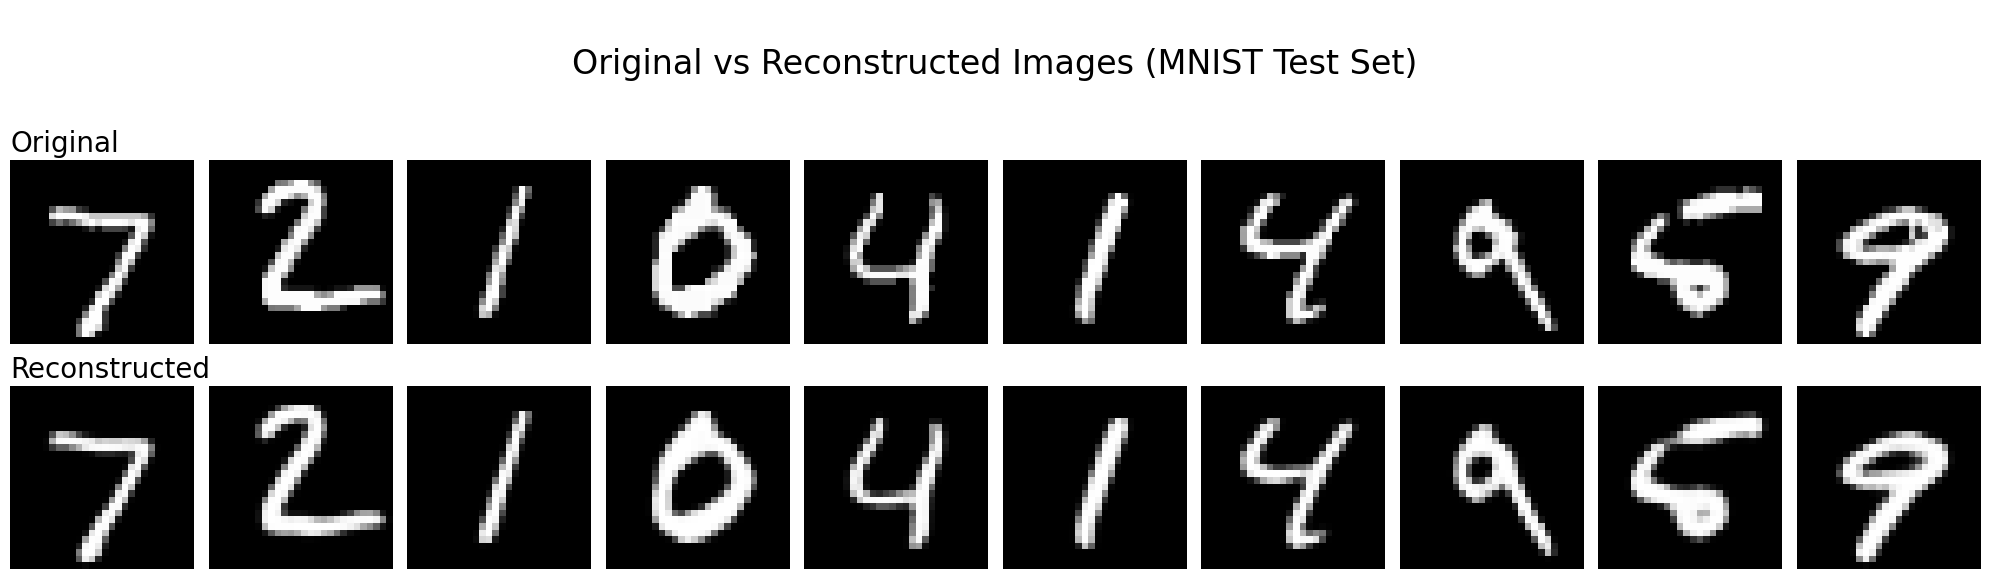

In [70]:
# Visualization of Original vs Reconstructed Images
n = 10
fig, axes = plt.subplots(2, n, figsize=(20, 6))

for i in range(n):
    # Original
    axes[0, i].imshow(original_imgs[i], cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Original", fontsize=20, loc="left")

    # Reconstructed
    axes[1, i].imshow(reconstructed_imgs[i], cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Reconstructed", fontsize=20, loc="left")

plt.suptitle("\nOriginal vs Reconstructed Images (MNIST Test Set)", fontsize=24, y=1.02)
plt.tight_layout()
plt.savefig("reconstruction.png", dpi=150)
plt.show()

### Observation:
* The reconstructed **images closely match the original digits**, showing that the autoencoder has learned the main structural features effectively.
* Most digits **retain their correct shape and are clearly recognizable**, although there is slight smoothing and minor loss of fine details.
* Overall, the model performs well in preserving essential patterns while removing noise.

In [78]:
# Check Final Training and Validation Loss
final_train_loss = history.history["loss"][-1]
final_val_loss   = history.history["val_loss"][-1]
print(f"\nFinal Training Loss   : {final_train_loss:.6f}")
print(f"Final Validation Loss : {final_val_loss:.6f}")


Final Training Loss   : 0.070869
Final Validation Loss : 0.070482


# Reconstruction Performance Analysis

In [76]:
# Check PSNR Score
def compute_psnr(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return 100
    return 10 * np.log10(1.0 / mse)

# Generate reconstructions for the entire test set
all_reconstructed_imgs_reshaped = autoencoder.predict(x_test_noisy_reshaped)

# The original images x_test_flat are (10000, 784)
all_reconstructed_imgs_flat = all_reconstructed_imgs_reshaped.reshape(-1, 784)

# Compute PSNR for test set
psnr_values = []

for i in range(len(x_test_flat)):
    psnr = compute_psnr(x_test_flat[i], all_reconstructed_imgs_flat[i])
    psnr_values.append(psnr)

avg_psnr = np.mean(psnr_values)
print("Average PSNR:", avg_psnr)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step
Average PSNR: 25.312206


## Observation:
The PSNR Score is **25.31**.

Which is in 20-30 dB range. That indicates that the model produces good quality reconstructions, realistic, and which is not overfitted.

In [77]:
# Check SSIM Score
ssim_values = []

for i in range(len(X_test)):
    original = X_test[i]
    reconstructed = all_reconstructed_imgs_reshaped[i].reshape(28, 28)

    ssim_score = ssim(original, reconstructed, data_range=1.0)
    ssim_values.append(ssim_score)

avg_ssim = np.mean(ssim_values)
print("Average SSIM:", avg_ssim)

Average SSIM: 0.9605946548226537


## Observation:
The SSIM Score is **0.96**.

1.0 --> Perfect Match

0.9 – 1.0 --> Excellent

0.7 – 0.9--> Decent

< 0.7 --> Poor

0.96 is very close to 1. This indicates that the reconstructed images preserve the structural information of the original images extremely well.

# **Autoencoder Results and Performance Analysis**

The autoencoder model is build using convolutional layers so it can capture the speacial pattersns in the MNIST digit images more effectively. **The encoder reduces each image into smaller latent representation**, and **the decoder then reconstructs the images from this compressed form**. **Noise was added to the input images** during the training, **so the model learns to remove noise and recover the original clean images**, making it a denoising autoencoder.

During the training, both the training and validation loss decreased consistently, which shows that the model was learning useful features without overfitting. **The reconstructed images are very close to the originals**, with **most of the noise removed and the main digit shapes preserved**. **The PSNR and SSIM values are also relatively high**, which confirms that the **model performs well not just visually** but also in terms of qualitative evaluation.